# Notebook 03 – Feature Engineering

## Objective

This notebook converts cleaned data into machine learning features.

It also creates reusable preprocessing pipelines.

# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# Load Cleaned Datasets

In [2]:
kaggle = pd.read_csv("../processed_data/kaggle_cleaned.csv")

survey = pd.read_csv("../processed_data/survey_cleaned.csv")

# Feature Engineering

The mobile application asks users to enter their previous three menstrual period lengths.

To simplify user input while maintaining predictive information, the average of the previous three period lengths is calculated and used as the predictor for period length prediction.

This ensures that the preprocessing performed during model training is identical to the preprocessing applied by the mobile application's backend during inference.

# Create Average Period Length

In [3]:
kaggle["Average_Previous_Period_Length"] = (
    kaggle[
        [
            "Prev_1_Period_Length",
            "Prev_2_Period_Length",
            "Prev_3_Period_Length"
        ]
    ].mean(axis=1)
)

In [4]:
survey["Average_Previous_Period_Length"] = (
    survey[
        [
            "Prev_1_Period_Length",
            "Prev_2_Period_Length",
            "Prev_3_Period_Length"
        ]
    ].mean(axis=1)
)

# Cycle Length Prediction Dataset

In [5]:
X_cycle = kaggle.drop(
    columns=[
        "Next_Cycle_Length",
        "Next_Period_Length"
    ]
)

y_cycle = kaggle["Next_Cycle_Length"]

# Train / Validation / Test Split

In [6]:
Xc_train, Xc_temp, yc_train, yc_temp = train_test_split(
    X_cycle,
    y_cycle,
    test_size=0.30,
    random_state=42
)

Xc_valid, Xc_test, yc_valid, yc_test = train_test_split(
    Xc_temp,
    yc_temp,
    test_size=0.50,
    random_state=42
)

# Random Forest Feature Importance

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(Xc_train, yc_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [8]:
feature_importance = pd.DataFrame({

    "Feature": Xc_train.columns,

    "Importance": rf.feature_importances_

}).sort_values(

    by="Importance",

    ascending=False

)

display(feature_importance)

,Feature,Importance
6,Prev_1_Cycle_Length,0.600137
28,Next_Is_Irregular,0.055919
1,BMI,0.038651
16,Sleep_Hours,0.034255
0,Age,0.028375
29,Confidence_Score,0.027054
8,Prev_3_Cycle_Length,0.022338
30,Average_Previous_Period_Length,0.020623
7,Prev_2_Cycle_Length,0.017264
2,Age_At_Menarche,0.016301


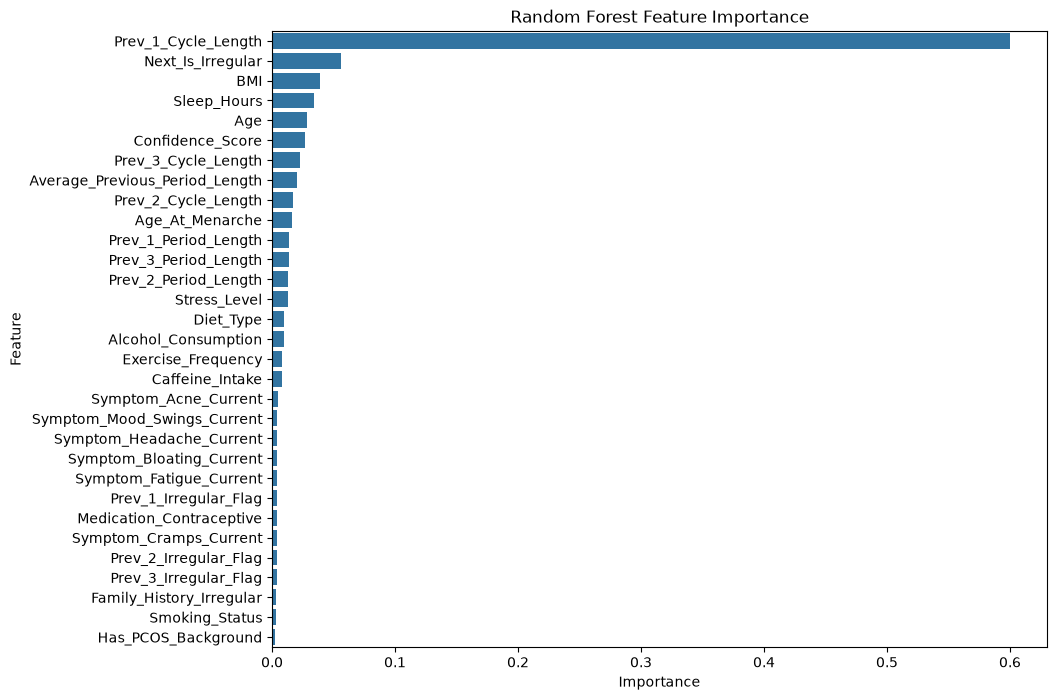

In [9]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

Feature	Justification

Age	-> Age influences hormonal regulation and menstrual cycle characteristics. Cycle regularity and length can change across different stages of reproductive life.

BMI -> 	Body Mass Index is associated with hormonal balance and ovulatory function. Both underweight and overweight individuals may experience changes in menstrual cycle length.

Age_At_Menarche	-> The age at first menstruation is an important reproductive health indicator and may reflect long-term menstrual characteristics.

Prev_1_Cycle_Length -> 	The most recent cycle length is the strongest predictor of the next cycle length, as confirmed by the highest Random Forest importance score.

Prev_2_Cycle_Length	-> Provides additional historical context and helps capture recurring cycle patterns.

Prev_3_Cycle_Length	-> Extends the historical trend and improves the model's ability to recognize longer-term variations.

Sleep_Hours	-> Sleep quality and duration influence hormonal regulation and have been associated with menstrual cycle variability.

Stress_Level ->	Psychological stress can affect hormone secretion and may contribute to changes in cycle timing and regularity.

Exercise_Frequency ->	Physical activity influences energy balance and endocrine function, making it a potentially relevant predictor of menstrual cycle characteristics.

Prev_1_Period_Length-> Previous menstrual duration provides complementary information about recent menstrual patterns that may improve prediction.

Prev_2_Period_Length ->	Captures additional historical menstrual duration information.

Prev_3_Period_Length ->	Represents longer-term menstrual duration history, complementing the previous two records.

Medication_Contraceptive ->	Hormonal contraceptives and certain medications can alter menstrual cycle characteristics and should be retained despite their relatively low Random Forest importance because of their clinical relevance.

# Feature selection

In [10]:
selected_features = [
    "Age",
    "BMI",
    "Age_At_Menarche",
    "Prev_1_Cycle_Length",
    "Prev_2_Cycle_Length",
    "Prev_3_Cycle_Length",
    "Prev_1_Period_Length",
    "Prev_2_Period_Length",
    "Prev_3_Period_Length",
    "Sleep_Hours",
    "Stress_Level",
    "Exercise_Frequency",
    "Medication_Contraceptive"
]

In [11]:
Xc_train = Xc_train[selected_features]
Xc_valid = Xc_valid[selected_features]
Xc_test = Xc_test[selected_features]

Feature selection was guided by Random Forest feature importance and domain knowledge. Features with high importance scores and established relevance to menstrual cycle prediction were retained. In addition, clinically meaningful variables such as medication/contraceptive use were preserved despite lower importance scores because they may influence menstrual cycle characteristics. Features representing future information (e.g., Next_Is_Irregular) or synthetic metadata (Confidence_Score) were excluded to prevent data leakage and ensure that only variables available at prediction time are used. This approach results in a model that is both accurate and suitable for deployment in the mobile application.

## Identifying Feature Types

After selecting the most relevant features, the remaining variables are categorized into numerical and categorical features.

This classification is required to build a preprocessing pipeline that applies the appropriate transformations to each feature type.

Numerical features will be standardized, while categorical features will be encoded using One-Hot Encoding.

In [12]:
numerical_features = Xc_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = Xc_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'BMI', 'Age_At_Menarche', 'Prev_1_Cycle_Length', 'Prev_2_Cycle_Length', 'Prev_3_Cycle_Length', 'Prev_1_Period_Length', 'Prev_2_Period_Length', 'Prev_3_Period_Length', 'Sleep_Hours', 'Stress_Level', 'Exercise_Frequency', 'Medication_Contraceptive']

Categorical Features:
[]


## Building the Preprocessing Pipeline

To ensure consistency between model training and deployment, all preprocessing operations are encapsulated within a Scikit-learn Pipeline.

The pipeline applies:

- StandardScaler to numerical variables
- One-Hot Encoding to categorical variables

The same pipeline will later be saved and reused by the mobile application's backend during inference.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Fit the Pipeline

In [14]:
preprocessor.fit(Xc_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

# Transform the Datasets

In [15]:
Xc_train_processed = preprocessor.transform(Xc_train)

Xc_valid_processed = preprocessor.transform(Xc_valid)

Xc_test_processed = preprocessor.transform(Xc_test)

# Save the Preprocessing Pipeline

In [16]:
import joblib

joblib.dump(
    preprocessor,
    "../models/cycle_preprocessing_pipeline.pkl"
)

['../models/cycle_preprocessing_pipeline.pkl']

# Save Processed Data

In [17]:
joblib.dump(
    Xc_train_processed,
    "../processed_data/Xc_train.pkl"
)

joblib.dump(
    Xc_valid_processed,
    "../processed_data/Xc_valid.pkl"
)

joblib.dump(
    Xc_test_processed,
    "../processed_data/Xc_test.pkl"

)

joblib.dump(
    yc_train,
    "../processed_data/yc_train.pkl"
)

joblib.dump(
    yc_valid,
    "../processed_data/yc_valid.pkl"
)

joblib.dump(
    yc_test,
    "../processed_data/yc_test.pkl"
)

['../processed_data/yc_test.pkl']

# Period Prediction Dataset

In [18]:
Xp = kaggle[["Average_Previous_Period_Length"]]

yp = kaggle["Next_Period_Length"]

# Split the data:

In [19]:
Xp_train, Xp_temp, yp_train, yp_temp = train_test_split(
    Xp,
    yp,
    test_size=0.30,
    random_state=42
)

Xp_valid, Xp_test, yp_valid, yp_test = train_test_split(
    Xp_temp,
    yp_temp,
    test_size=0.50,
    random_state=42
)

# Scale the single numerical feature:

In [20]:

period_scaler = StandardScaler()

Xp_train_processed = period_scaler.fit_transform(Xp_train)

Xp_valid_processed = period_scaler.transform(Xp_valid)

Xp_test_processed = period_scaler.transform(Xp_test)

# Save the scaler:

In [21]:
joblib.dump(
    period_scaler,
    "../models/period_scaler.pkl"
)

['../models/period_scaler.pkl']

# Save the processed period data:

In [22]:
joblib.dump(Xp_train_processed, "../processed_data/Xp_train.pkl")
joblib.dump(Xp_valid_processed, "../processed_data/Xp_valid.pkl")
joblib.dump(Xp_test_processed, "../processed_data/Xp_test.pkl")

joblib.dump(yp_train, "../processed_data/yp_train.pkl")
joblib.dump(yp_valid, "../processed_data/yp_valid.pkl")
joblib.dump(yp_test, "../processed_data/yp_test.pkl")

['../processed_data/yp_test.pkl']